In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

In [30]:
# Load the cleaned dataset created in Milestone-1

df = pd.read_csv(r"C:\Users\RISHI\Desktop\USND\notebooks\datasets.csv")

# Display first few rows to understand the dataset
print(df.head())

  declarationNumber declarationType declarationDate state county incidentType  \
0              DR-1        Disaster      1953-05-02    GA    NaN      Tornado   
1              DR-2        Disaster      1953-05-15    TX    NaN      Tornado   
2              DR-3        Disaster      1953-05-29    LA    NaN        Flood   
3              DR-4        Disaster      1953-06-02    MI    NaN      Tornado   
4              DR-5        Disaster      1953-06-06    MT    NaN        Flood   

                incidentTitle   startDate     endDate   closeDate  \
0                     Tornado  05/02/1953  05/02/1953  06/01/1954   
1  Tornado and Heavy Rainfall  05/15/1953  05/15/1953  01/01/1958   
2                       Flood  05/29/1953  05/29/1953  02/01/1960   
3                     Tornado  06/02/1953  06/02/1953  02/01/1956   
4                      Floods  06/06/1953  06/06/1953  12/01/1955   

  individualAssistanceProgram individualsAndHouseholdsProgram  \
0                         Yes    

In [31]:
freq = df['incidentType'].value_counts().reset_index()
freq.columns = ['incidentType', 'count']

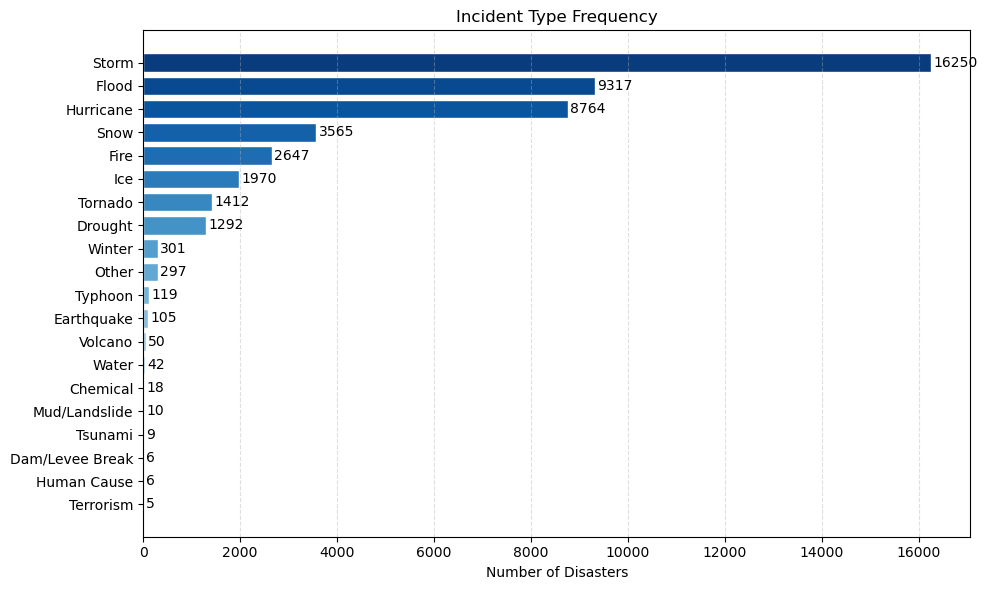

In [32]:
palette = sns.color_palette('Blues_r', len(freq))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(freq['incidentType'], freq['count'],
               color=palette, edgecolor='white')

for bar, val in zip(bars, freq['count']):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'{val}', va='center')

ax.set_xlabel('Number of Disasters')
ax.set_title('Incident Type Frequency')
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [33]:
fig = px.treemap(
    freq,
    path=['incidentType'],
    values='count',
    color='count',
    color_continuous_scale='Reds',
    title='Incident Type Distribution (Treemap)'
)

fig.show()

In [34]:
top_states = df['state'].value_counts().head(15).index.tolist()

df_top = df[df['state'].isin(top_states)]

pivot = (df_top
         .groupby(['state', 'incidentType'])
         .size()
         .unstack(fill_value=0)
         .loc[top_states])

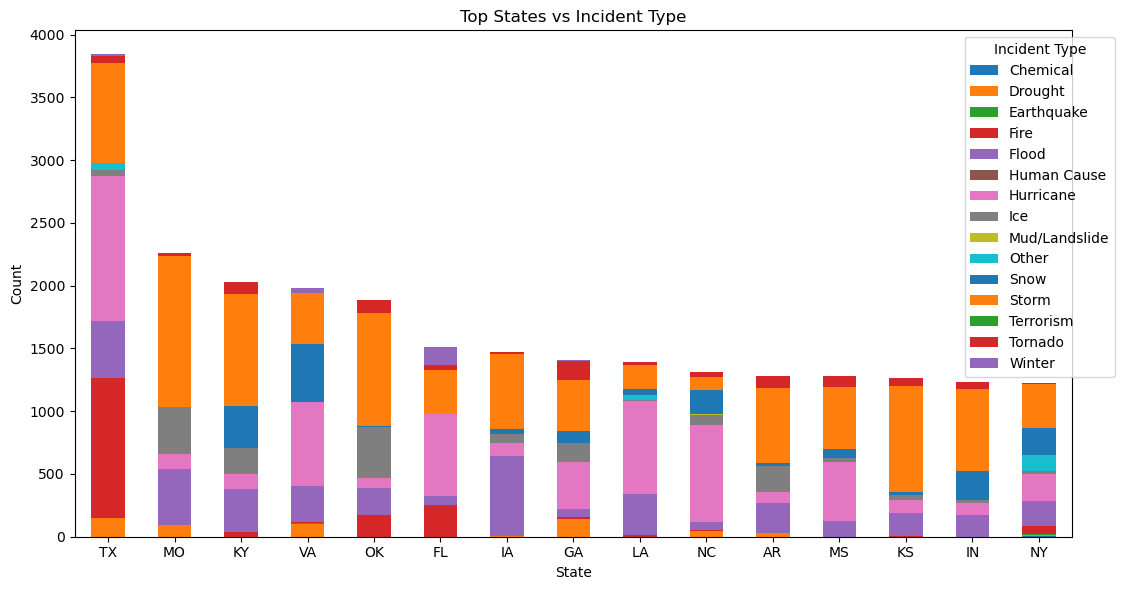

In [35]:
pivot.plot(kind='bar', stacked=True, figsize=(13, 6))

plt.title('Top States vs Incident Type')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Incident Type', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

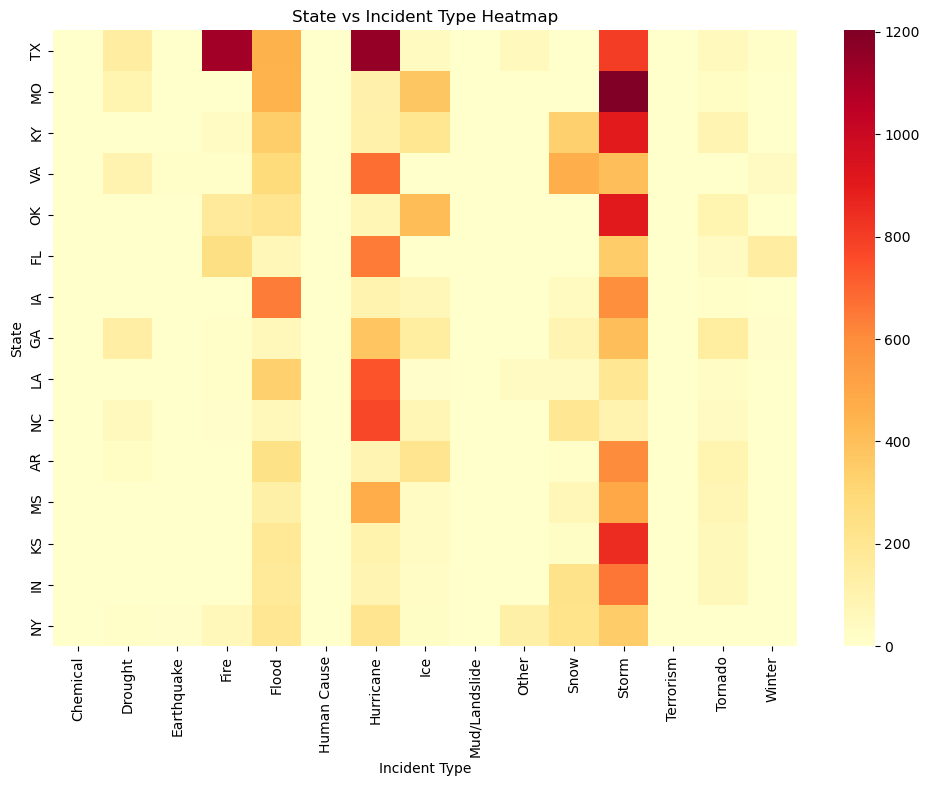

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(pivot, cmap='YlOrRd')

plt.title('State vs Incident Type Heatmap')
plt.xlabel('Incident Type')
plt.ylabel('State')

plt.show()

In [37]:
# Convert Yes/No → 1/0
df['individualAssistanceProgram'] = df['individualAssistanceProgram'].map({'Yes':1, 'No':0})
df['publicAssistanceProgram'] = df['publicAssistanceProgram'].map({'Yes':1, 'No':0})

# Fill missing values
df[['individualAssistanceProgram', 'publicAssistanceProgram']] = df[
    ['individualAssistanceProgram', 'publicAssistanceProgram']
].fillna(0)

# Grouping
assistance = (df.groupby('incidentType')
              [['individualAssistanceProgram', 'publicAssistanceProgram']]
              .sum()
              .reset_index())

assistance

,incidentType,individualAssistanceProgram,publicAssistanceProgram
0,Chemical,3,17
1,Dam/Levee Break,1,6
2,Drought,61,1287
3,Earthquake,79,98
4,Fire,713,2498
5,Flood,6753,9143
6,Human Cause,1,6
7,Hurricane,2962,8720
8,Ice,355,1960
9,Mud/Landslide,3,10


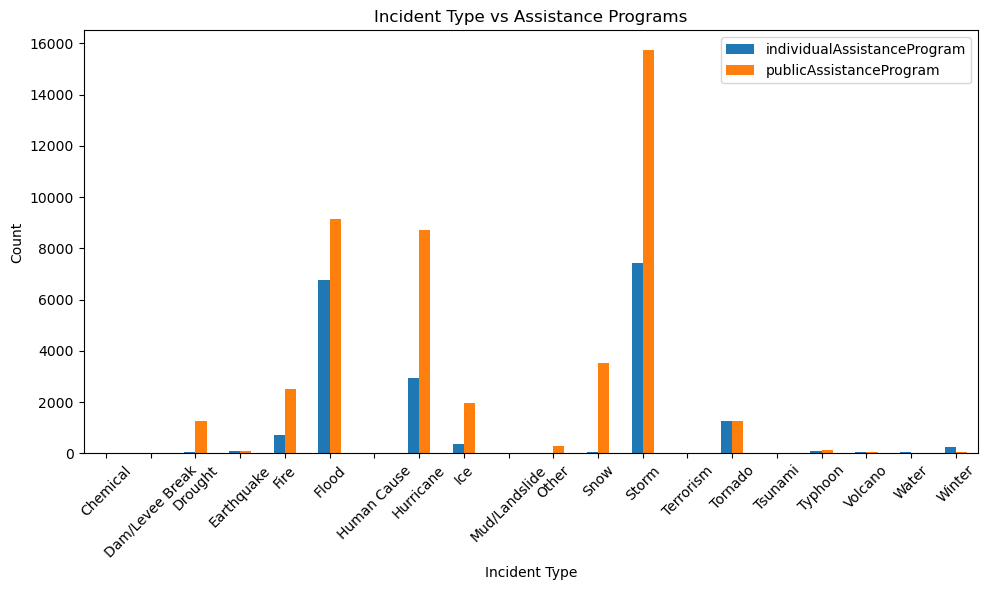

In [38]:
assistance.set_index('incidentType').plot(kind='bar', figsize=(10,6))

plt.title('Incident Type vs Assistance Programs')
plt.ylabel('Count')
plt.xlabel('Incident Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
annual = (df.groupby(['year', 'incidentType'])
          .size()
          .reset_index(name='count'))

# Get top 5 incident types
top5 = df['incidentType'].value_counts().head(5).index

annual_top = annual[annual['incidentType'].isin(top5)]

import plotly.express as px

fig = px.line(
    annual_top,
    x='year',
    y='count',
    color='incidentType',
    markers=True,
    title='Yearly Trend of Top Incident Types'
)

fig.show()

In [40]:
state_type = (df.groupby(['state', 'incidentType'])
              .size()
              .reset_index(name='count'))

import plotly.express as px

fig = px.scatter(
    state_type,
    x='state',
    y='incidentType',
    size='count',
    color='incidentType',
    title='State vs Incident Type Bubble Chart'
)

fig.show()